In [1]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/ ({len(files)} files)")
    if level < 3:
        for f in files[:5]:
            print(f"{indent}  - {f}")

input/ (0 files)
  datasets/ (0 files)
    sshikamaru/ (0 files)
      drone-yolo-detection/ (1 files)
        Database1/ (0 files)
          Database1/ (8025 files)
    organizations/ (0 files)
      airbusgeo/ (0 files)
        airbus-aircrafts-sample-dataset/ (3 files)
          images/ (103 files)
          extras/ (6 files)


In [2]:
import os
from collections import Counter

paths = [
    "/kaggle/input/datasets/organizations/airbusgeo/airbus-aircrafts-sample-dataset",
    "/kaggle/input/datasets/sshikamaru/drone-yolo-detection/Database1/Database1"
]

for base in paths:
    print("\n" + "="*80)
    print(base)
    print("="*80)
    
    ext_counter = Counter()
    sample_files = []
    
    for root, dirs, files in os.walk(base):
        for f in files:
            ext = os.path.splitext(f)[1].lower()
            ext_counter[ext] += 1
            if len(sample_files) < 30:
                sample_files.append(os.path.join(root, f))
    
    print("Extensions:", ext_counter)
    print("\nSample files:")
    for f in sample_files:
        print(f)


/kaggle/input/datasets/organizations/airbusgeo/airbus-aircrafts-sample-dataset
Extensions: Counter({'.jpg': 109, '.md': 1, '.txt': 1, '.csv': 1})

Sample files:
/kaggle/input/datasets/organizations/airbusgeo/airbus-aircrafts-sample-dataset/README.md
/kaggle/input/datasets/organizations/airbusgeo/airbus-aircrafts-sample-dataset/LICENSE.txt
/kaggle/input/datasets/organizations/airbusgeo/airbus-aircrafts-sample-dataset/annotations.csv
/kaggle/input/datasets/organizations/airbusgeo/airbus-aircrafts-sample-dataset/images/71252436-5176-40ba-b1ff-73efc251f3c6.jpg
/kaggle/input/datasets/organizations/airbusgeo/airbus-aircrafts-sample-dataset/images/54442e49-5271-42bf-a8fb-a2cab30cfd49.jpg
/kaggle/input/datasets/organizations/airbusgeo/airbus-aircrafts-sample-dataset/images/03f84930-e2be-4c19-9afc-0dc26d02538e.jpg
/kaggle/input/datasets/organizations/airbusgeo/airbus-aircrafts-sample-dataset/images/48ef8e15-a43c-406b-9d3c-e815164b96d1.jpg
/kaggle/input/datasets/organizations/airbusgeo/airbus-a

In [3]:
import pandas as pd
import os

# Airbus CSV
airbus_csv = "/kaggle/input/datasets/organizations/airbusgeo/airbus-aircrafts-sample-dataset/annotations.csv"
df = pd.read_csv(airbus_csv)

print("AIRBUS CSV COLUMNS:")
print(df.columns)
print("\nAIRBUS FIRST ROWS:")
print(df.head())

# Drone TXT sample
drone_dir = "/kaggle/input/datasets/sshikamaru/drone-yolo-detection/Database1/Database1"

txt_files = [f for f in os.listdir(drone_dir) if f.lower().endswith(".txt")]
print("\nNumber of drone txt labels:", len(txt_files))
print("Sample txt file:", txt_files[0])

with open(os.path.join(drone_dir, txt_files[0]), "r") as f:
    print("\nDRONE TXT CONTENT:")
    print(f.read()[:500])

AIRBUS CSV COLUMNS:
Index(['id', 'image_id', 'geometry', 'class'], dtype='object')

AIRBUS FIRST ROWS:
   id                                  image_id  \
0   1  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
1   2  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
2   3  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
3   4  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
4   5  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   

                                            geometry     class  
0  [(135, 522), (245, 522), (245, 600), (135, 600...  Airplane  
1  [(1025, 284), (1125, 284), (1125, 384), (1025,...  Airplane  
2  [(1058, 1503), (1130, 1503), (1130, 1568), (10...  Airplane  
3  [(813, 1518), (885, 1518), (885, 1604), (813, ...  Airplane  
4  [(594, 938), (657, 938), (657, 1012), (594, 10...  Airplane  

Number of drone txt labels: 4010
Sample txt file: video16_141.txt

DRONE TXT CONTENT:
0 0.534375 0.314583333333 0.26875 0.290277777778



In [4]:
import os
import shutil
import ast
import random
from pathlib import Path
from PIL import Image
import pandas as pd

random.seed(42)

# Input paths
AIRBUS_BASE = Path("/kaggle/input/datasets/organizations/airbusgeo/airbus-aircrafts-sample-dataset")
AIRBUS_IMG_DIR = AIRBUS_BASE / "images"
AIRBUS_CSV = AIRBUS_BASE / "annotations.csv"

DRONE_DIR = Path("/kaggle/input/datasets/sshikamaru/drone-yolo-detection/Database1/Database1")

# Output dataset
OUT = Path("/kaggle/working/dataset")

for split in ["train", "val", "test"]:
    (OUT / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUT / "labels" / split).mkdir(parents=True, exist_ok=True)

def yolo_from_xyxy(xmin, ymin, xmax, ymax, img_w, img_h):
    x_center = ((xmin + xmax) / 2) / img_w
    y_center = ((ymin + ymax) / 2) / img_h
    width = (xmax - xmin) / img_w
    height = (ymax - ymin) / img_h
    return x_center, y_center, width, height

def split_name():
    r = random.random()
    if r < 0.70:
        return "train"
    elif r < 0.85:
        return "val"
    else:
        return "test"

# -------------------------
# 1. Airbus airplane dataset
# -------------------------
df = pd.read_csv(AIRBUS_CSV)

# group annotations by image
airbus_grouped = df.groupby("image_id")

airbus_count = 0

for image_name, group in airbus_grouped:
    img_path = AIRBUS_IMG_DIR / image_name
    if not img_path.exists():
        continue

    with Image.open(img_path) as img:
        w, h = img.size

    split = split_name()
    new_stem = f"airplane_{Path(image_name).stem}"
    new_img_name = new_stem + ".jpg"
    new_label_name = new_stem + ".txt"

    shutil.copy(img_path, OUT / "images" / split / new_img_name)

    label_lines = []

    for _, row in group.iterrows():
        points = ast.literal_eval(row["geometry"])  # [(x,y), (x,y), ...]
        xs = [p[0] for p in points]
        ys = [p[1] for p in points]

        xmin, xmax = min(xs), max(xs)
        ymin, ymax = min(ys), max(ys)

        x, y, bw, bh = yolo_from_xyxy(xmin, ymin, xmax, ymax, w, h)

        # class 0 = airplane
        label_lines.append(f"0 {x:.6f} {y:.6f} {bw:.6f} {bh:.6f}")

    with open(OUT / "labels" / split / new_label_name, "w") as f:
        f.write("\n".join(label_lines))

    airbus_count += 1

# -------------------------
# 2. Drone dataset
# -------------------------
drone_images = [p for p in DRONE_DIR.iterdir() if p.suffix.lower() in [".jpg", ".jpeg", ".png"]]

drone_count = 0
missing_label_count = 0

for img_path in drone_images:
    label_path = img_path.with_suffix(".txt")
    
    # Some files are .JPEG but labels still use same stem + .txt
    if not label_path.exists():
        label_path = DRONE_DIR / (img_path.stem + ".txt")
    
    if not label_path.exists():
        missing_label_count += 1
        continue

    split = split_name()
    new_stem = f"drone_{img_path.stem}"
    new_img_name = new_stem + img_path.suffix.lower()
    new_label_name = new_stem + ".txt"

    shutil.copy(img_path, OUT / "images" / split / new_img_name)

    new_lines = []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                # change class to 1 = drone
                new_lines.append("1 " + " ".join(parts[1:]))

    with open(OUT / "labels" / split / new_label_name, "w") as f:
        f.write("\n".join(new_lines))

    drone_count += 1

# -------------------------
# 3. data.yaml
# -------------------------
yaml_text = """path: /kaggle/working/dataset
train: images/train
val: images/val
test: images/test

names:
  0: airplane
  1: drone
"""

with open(OUT / "data.yaml", "w") as f:
    f.write(yaml_text)

# -------------------------
# 4. Summary
# -------------------------
print("Dataset created at:", OUT)
print("Airbus airplane images used:", airbus_count)
print("Drone images used:", drone_count)
print("Drone images missing labels:", missing_label_count)

for split in ["train", "val", "test"]:
    img_n = len(list((OUT / "images" / split).glob("*")))
    lbl_n = len(list((OUT / "labels" / split).glob("*.txt")))
    print(f"{split}: {img_n} images, {lbl_n} labels")

print("\ndata.yaml:")
print(open(OUT / "data.yaml").read())

Dataset created at: /kaggle/working/dataset
Airbus airplane images used: 103
Drone images used: 4010
Drone images missing labels: 4
train: 2881 images, 2881 labels
val: 643 images, 643 labels
test: 589 images, 589 labels

data.yaml:
path: /kaggle/working/dataset
train: images/train
val: images/val
test: images/test

names:
  0: airplane
  1: drone



In [5]:
from pathlib import Path
from collections import Counter

OUT = Path("/kaggle/working/dataset")

for split in ["train", "val", "test"]:
    label_dir = OUT / "labels" / split
    class_counter = Counter()
    empty_labels = 0

    for label_file in label_dir.glob("*.txt"):
        text = label_file.read_text().strip()
        if not text:
            empty_labels += 1
            continue

        for line in text.splitlines():
            cls = line.split()[0]
            class_counter[cls] += 1

    print(f"\n{split}")
    print("class counts:", class_counter)
    print("empty labels:", empty_labels)


train
class counts: Counter({'0': 2594, '1': 2376})
empty labels: 777

val
class counts: Counter({'1': 493, '0': 358})
empty labels: 200

test
class counts: Counter({'1': 473, '0': 473})
empty labels: 168


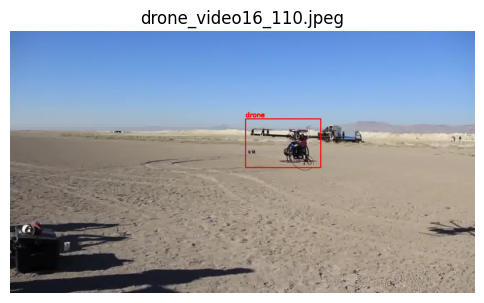

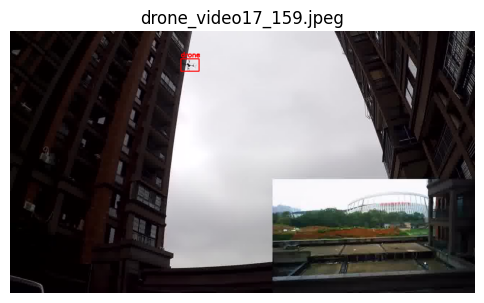

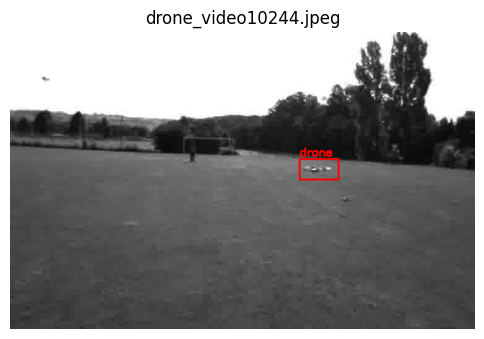

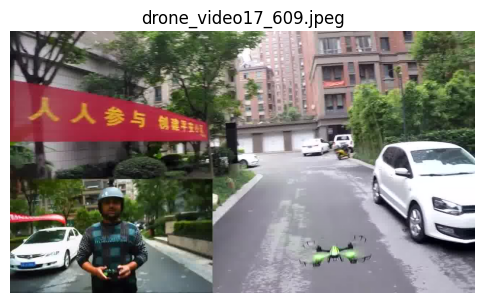

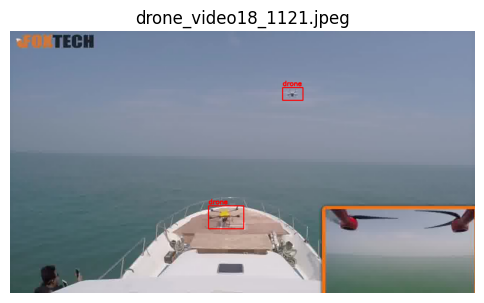

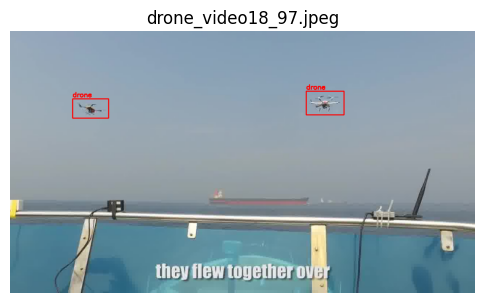

In [6]:
import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path("/kaggle/working/dataset")
split = "train"

img_files = list((OUT / "images" / split).glob("*"))
sample_imgs = random.sample(img_files, 6)

class_names = {0: "airplane", 1: "drone"}

for img_path in sample_imgs:
    label_path = OUT / "labels" / split / (img_path.stem + ".txt")

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            cls, x, y, bw, bh = map(float, line.split())
            cls = int(cls)

            x1 = int((x - bw / 2) * w)
            y1 = int((y - bh / 2) * h)
            x2 = int((x + bw / 2) * w)
            y2 = int((y + bh / 2) * h)

            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(img, class_names[cls], (x1, max(y1 - 5, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name)
    plt.show()

In [7]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU: Tesla T4


In [8]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.7 MB/s eta 0:00:00


In [9]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/kaggle/working/dataset/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    project="/kaggle/working/runs",
    name="yolov8n_airplane_drone_first_test"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.

In [10]:
metrics = model.val(
    data="/kaggle/working/dataset/data.yaml",
    split="test"
)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 575.8±298.6 MB/s, size: 19.7 KB)
val: Scanning /kaggle/working/dataset/labels/test... 589 images, 168 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 589/589 1.4Kit/s 0.4s
val: New cache created: /kaggle/working/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 8.6it/s 4.3s
                   all        589        946      0.887      0.845      0.906       0.53
              airplane         14        473        0.9      0.876      0.912      0.574
                 drone        407        473      0.873      0.814      0.901      0.486
Speed: 0.7ms preprocess, 2.5ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /kaggle/working/runs/detect/val


In [11]:
import shutil
from pathlib import Path

src = Path("/kaggle/working/runs/yolov8n_airplane_drone_first_test")
dst = Path("/kaggle/working/first_training_results")

if dst.exists():
    shutil.rmtree(dst)

shutil.copytree(src, dst)

print("Copied results to:", dst)
print("Files:")
for p in dst.iterdir():
    print(p.name)

Copied results to: /kaggle/working/first_training_results
Files:
confusion_matrix_normalized.png
BoxP_curve.png
weights
val_batch0_pred.jpg
BoxPR_curve.png
train_batch1.jpg
results.csv
val_batch1_pred.jpg
args.yaml
confusion_matrix.png
val_batch0_labels.jpg
BoxF1_curve.png
train_batch2.jpg
val_batch2_pred.jpg
val_batch2_labels.jpg
results.png
labels.jpg
val_batch1_labels.jpg
train_batch0.jpg
BoxR_curve.png


In [12]:
!ls -lah /kaggle/working/first_training_results

total 3.8M
drwxr-xr-x 3 root root 4.0K May 18 13:50 .
drwxr-xr-x 5 root root 4.0K May 18 13:50 ..
-rw-r--r-- 1 root root 1.7K May 18 13:44 args.yaml
-rw-r--r-- 1 root root 167K May 18 13:50 BoxF1_curve.png
-rw-r--r-- 1 root root 132K May 18 13:50 BoxP_curve.png
-rw-r--r-- 1 root root 113K May 18 13:50 BoxPR_curve.png
-rw-r--r-- 1 root root 145K May 18 13:50 BoxR_curve.png
-rw-r--r-- 1 root root 113K May 18 13:50 confusion_matrix_normalized.png
-rw-r--r-- 1 root root 105K May 18 13:50 confusion_matrix.png
-rw-r--r-- 1 root root 106K May 18 13:44 labels.jpg
-rw-r--r-- 1 root root 1.4K May 18 13:49 results.csv
-rw-r--r-- 1 root root 271K May 18 13:50 results.png
-rw-r--r-- 1 root root 341K May 18 13:44 train_batch0.jpg
-rw-r--r-- 1 root root 431K May 18 13:44 train_batch1.jpg
-rw-r--r-- 1 root root 325K May 18 13:44 train_batch2.jpg
-rw-r--r-- 1 root root 243K May 18 13:49 val_batch0_labels.jpg
-rw-r--r-- 1 root root 252K May 18 13:49 val_batch0_pred.jpg
-rw-r--r-- 1 root root 242K May 18

In [13]:
import shutil
from pathlib import Path

src = Path("/kaggle/working/runs/yolov8n_airplane_drone_first_test")
dst = Path("/kaggle/working/first_training_results")

if dst.exists():
    shutil.rmtree(dst)

shutil.copytree(src, dst)

print("Saved to:", dst)

Saved to: /kaggle/working/first_training_results


In [14]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/kaggle/working/dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    project="/kaggle/working/runs",
    name="yolov8n_airplane_drone_30epochs"
)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_airplane_drone_30epochs, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

In [15]:
metrics = model.val(
    data="/kaggle/working/dataset/data.yaml",
    split="test"
)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 644.1±379.9 MB/s, size: 19.7 KB)
val: Scanning /kaggle/working/dataset/labels/test.cache... 589 images, 168 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 589/589 205.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 8.4it/s 4.4s
                   all        589        946      0.916      0.882      0.918      0.555
              airplane         14        473      0.951      0.892      0.917      0.601
                 drone        407        473       0.88      0.871       0.92      0.509
Speed: 0.8ms preprocess, 2.3ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2


In [16]:
import shutil
from pathlib import Path

src = Path("/kaggle/working/runs/yolov8n_airplane_drone_30epochs")
dst = Path("/kaggle/working/2nd_training_results")

if dst.exists():
    shutil.rmtree(dst)

shutil.copytree(src, dst)

print("Saved to:", dst)

Saved to: /kaggle/working/2nd_training_results


In [17]:
!zip -r /kaggle/working/2nd_training_results.zip /kaggle/working/2nd_training_results

  adding: kaggle/working/2nd_training_results/ (stored 0%)
  adding: kaggle/working/2nd_training_results/confusion_matrix_normalized.png (deflated 31%)
  adding: kaggle/working/2nd_training_results/BoxP_curve.png (deflated 13%)
  adding: kaggle/working/2nd_training_results/train_batch3601.jpg (deflated 24%)
  adding: kaggle/working/2nd_training_results/weights/ (stored 0%)
  adding: kaggle/working/2nd_training_results/weights/last.pt (deflated 10%)
  adding: kaggle/working/2nd_training_results/weights/best.pt (deflated 10%)
  adding: kaggle/working/2nd_training_results/val_batch0_pred.jpg (deflated 14%)
  adding: kaggle/working/2nd_training_results/BoxPR_curve.png (deflated 19%)
  adding: kaggle/working/2nd_training_results/train_batch1.jpg (deflated 9%)
  adding: kaggle/working/2nd_training_results/train_batch3602.jpg (deflated 22%)
  adding: kaggle/working/2nd_training_results/results.csv (deflated 60%)
  adding: kaggle/working/2nd_training_results/val_batch1_pred.jpg (deflated 14%)


In [18]:
!ls -lah /kaggle/working | grep 2nd

drwxr-xr-x 3 root root 4.0K May 18 14:07 2nd_training_results
-rw-r--r-- 1 root root  15M May 18 14:07 2nd_training_results.zip
